## Caso 3 - Visalização Livre

> Eu sempre fui um amante da sétima arte, e sempre na conversar com os amigos, a gente nota, a volta de uma onda já vivida, como a volta do "TODO MUNDO EM PÂNICO", o que deve acarretar em outros lançamntos do tema comedia pastelão.

> Como temos um histórico de filmes, vou tentar encontrar alguma relação.
> Acredito que dados com contextos, contam historias. 

In [1]:
# link do notebook com o sistema
import sys
import os


root = "/home/santanna/develope/projetos/data-challenge_luiz_bernardo"
# raiz do projeto
if root not in sys.path:
    sys.path.insert(0, root)

print(sys.path[0])  # confirma

/home/santanna/develope/projetos/data-challenge_luiz_bernardo


In [2]:
# importações
from src.models.repositories.imdb_repository import ImdbRepository
import matplotlib.pyplot as plt
from typing import List
import pandas as pd

repo = ImdbRepository()

In [14]:
# base de dados 
base = repo.read_db()
base.describe, base.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Id               1000 non-null   int64  
 1   Title            1000 non-null   str    
 2   Genre            1000 non-null   str    
 3   Director         1000 non-null   str    
 4   Actors           1000 non-null   str    
 5   Year             1000 non-null   int64  
 6   Runtime          1000 non-null   int64  
 7   Rating           1000 non-null   float64
 8   Votes            1000 non-null   int64  
 9   RevenueMillions  872 non-null    float64
 10  Metascore        936 non-null    float64
dtypes: float64(3), int64(4), str(4)
memory usage: 86.1 KB


(<bound method NDFrame.describe of        Id                    Title  ... RevenueMillions Metascore
 0       1  Guardians of the Galaxy  ...           333.0      76.0
 1       2               Prometheus  ...           126.0      65.0
 2       3                    Split  ...           138.0      62.0
 3       4                     Sing  ...           270.0      59.0
 4       5            Suicide Squad  ...           325.0      40.0
 ..    ...                      ...  ...             ...       ...
 995   996     Secret in Their Eyes  ...             NaN      45.0
 996   997          Hostel: Part II  ...            18.0      46.0
 997   998   Step Up 2: The Streets  ...            58.0      50.0
 998   999             Search Party  ...             NaN      22.0
 999  1000               Nine Lives  ...            20.0      11.0
 
 [1000 rows x 11 columns]>,
 None)

In [ ]:
# base explorando
"""
generos são listas de sub temas, podemos usar isso.
"""

base_genre = (
    base
    .groupby(['Genre'])
)

base_genre

,Id,Title,Genre,Director,Actors,Year,Runtime,Rating,Votes,RevenueMillions,Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.0,757074,333.0,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.0,65.0
2,3,Split,"Horror,Thriller",M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.0,157606,138.0,62.0
3,4,Sing,"Animation,Comedy,Family",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.0,60545,270.0,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.0,393727,325.0,40.0
...,...,...,...,...,...,...,...,...,...,...,...
991,992,Taare Zameen Par,"Drama,Family,Music",Aamir Khan,"Darsheel Safary, Aamir Khan, Tanay Chheda, Sac...",2007,165,9.0,102697,1.0,42.0
993,994,Resident Evil: Afterlife,"Action,Adventure,Horror",Paul W.S. Anderson,"Milla Jovovich, Ali Larter, Wentworth Miller,K...",2010,97,6.0,140900,60.0,37.0
997,998,Step Up 2: The Streets,"Drama,Music,Romance",Jon M. Chu,"Robert Hoffman, Briana Evigan, Cassie Ventura,...",2008,98,6.0,70699,58.0,50.0
998,999,Search Party,"Adventure,Comedy",Scot Armstrong,"Adam Pally, T.J. Miller, Thomas Middleditch,Sh...",2014,93,6.0,4881,NaN,22.0


In [62]:
# separa os gêneros e explode — uma linha por gênero
base_imdb = (
    base
    .assign(Genre=base["Genre"].str.split(","))
    .explode("Genre")
)

base_imdb["Genre"] = base_imdb["Genre"].str.strip()

print(base_imdb.head())

print(base_imdb["Genre"].value_counts().head(15))
print(f"\nTotal de linhas após explode: {len(base_imdb)}")

   Id                    Title      Genre  ...   Votes RevenueMillions  Metascore
0   1  Guardians of the Galaxy     Action  ...  757074           333.0       76.0
0   1  Guardians of the Galaxy  Adventure  ...  757074           333.0       76.0
0   1  Guardians of the Galaxy     Sci-Fi  ...  757074           333.0       76.0
1   2               Prometheus  Adventure  ...  485820           126.0       65.0
1   2               Prometheus    Mystery  ...  485820           126.0       65.0

[5 rows x 11 columns]
Genre
Drama        513
Action       303
Comedy       279
Adventure    259
Thriller     195
Crime        150
Romance      141
Sci-Fi       120
Horror       119
Mystery      106
Fantasy      101
Biography     81
Family        51
Animation     49
History       29
Name: count, dtype: int64

Total de linhas após explode: 2555


In [28]:
base_agr = (
    base_imdb
    .groupby(["Year", "Genre"])
    .agg(
        count = ("Id", "count"),
        avg_rating = ("Rating", "mean"),
        avg_revenue = ("RevenueMillions", "mean")
    )
    .reset_index()
)
base_agr

,Year,Genre,count,avg_rating,avg_revenue
0,2006,Action,11,7.000000,166.300000
1,2006,Adventure,13,7.153846,122.846154
2,2006,Animation,2,7.000000,221.000000
3,2006,Biography,3,7.000000,61.333333
4,2006,Comedy,12,7.000000,76.250000
...,...,...,...,...,...
190,2016,Sci-Fi,20,6.250000,130.800000
191,2016,Sport,5,6.800000,4.666667
192,2016,Thriller,60,6.183333,30.387097
193,2016,War,3,6.666667,1.500000


In [42]:
base_terror = base_agr.loc[base_agr["Genre"] == "Horror"]

base_terror

,Year,Genre,count,avg_rating,avg_revenue
10,2006,Horror,4,6.750000,24.750000
28,2007,Horror,11,6.818182,58.000000
45,2008,Horror,4,6.500000,44.333333
63,2009,Horror,7,6.285714,29.857143
79,2010,Horror,8,6.125000,27.285714
95,2011,Horror,3,5.666667,40.500000
112,2012,Horror,5,6.200000,54.800000
130,2013,Horror,13,6.384615,56.384615
148,2014,Horror,8,6.500000,19.571429
167,2015,Horror,11,6.090909,20.000000


In [43]:
import plotly.express as px

# linha de comédia por ano
fig = px.line(
    base_terror,
    x="Year",
    y="count",
    markers=True,
    title="Volume de Filmes de Comédia por Ano",
    labels={"count": "Quantidade de Filmes", "Year": "Ano"}
)

fig.update_traces(line_color="#e76f51", line_width=3, marker_size=8)
fig.update_layout(
    template="plotly_white",
    title_font_size=16
)

fig.show()

## Análise Parcial 

> Não podemos prosseguir, pois temos um espaço temporal muito curto para fazer uma análise periodica de interesse sobre os temas dos filmes.

> Mas análisando os dados podemos fazer uma analise interessante.
> podemos fazer uma analise a partir do faturamento junto com as quantidades de votos e o valor final dos votos, para buscar filmes que fizeram sucesso, vendo sucesso como filmes que tiveram faturamento, total de votos e nota acima da média 

* Já podemos ver nos anos finais um pico, reflexo dos Streammes?

In [66]:
# Buscando as medias base

base_means = (
    base
    .groupby(["Year"])
    .agg(
        count = ("Id", "count"),
        avg_rating = ("Rating", "mean"),
        avg_revenue = ("RevenueMillions", "mean"),
        avg_votes = ("Votes", "mean")
    )
    .reset_index()
    .round(1)
)
base_means

,Year,count,avg_rating,avg_revenue,avg_votes
0,2006,44,7.3,86.2,269290.0
1,2007,53,7.2,87.9,244331.0
2,2008,52,6.8,99.1,275505.4
3,2009,51,7.1,112.6,255780.6
4,2010,60,6.9,105.1,252782.3
5,2011,63,6.9,87.6,240790.3
6,2012,64,6.9,108.0,285226.1
7,2013,91,6.9,87.1,219049.6
8,2014,98,6.9,85.1,203930.2
9,2015,127,6.6,78.3,115726.2


In [ ]:
# buscando os filmes de sucesso 
"""
deixei pois vocês queriam ver a linha de raciocinio 

for x in  base_means:
    print("isso é x",x)
    for y in base_means:
        print("isso é y",base_means[y])
"""

_IncompleteInputError: incomplete input (2738720405.py, line 2)

In [67]:
# montando tabela de sucessos

base_greate = pd.merge(base_imdb, base_means, on= "Year", how= "left")

base_greate

,Id,Title,Genre,Director,Actors,Year,Runtime,Rating,Votes,RevenueMillions,Metascore,count,avg_rating,avg_revenue,avg_votes
0,1,Guardians of the Galaxy,Action,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.0,757074,333.0,76.0,98,6.9,85.1,203930.2
1,1,Guardians of the Galaxy,Adventure,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.0,757074,333.0,76.0,98,6.9,85.1,203930.2
2,1,Guardians of the Galaxy,Sci-Fi,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.0,757074,333.0,76.0,98,6.9,85.1,203930.2
3,2,Prometheus,Adventure,Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.0,65.0,64,6.9,108.0,285226.1
4,2,Prometheus,Mystery,Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.0,65.0,64,6.9,108.0,285226.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2550,999,Search Party,Adventure,Scot Armstrong,"Adam Pally, T.J. Miller, Thomas Middleditch,Sh...",2014,93,6.0,4881,NaN,22.0,98,6.9,85.1,203930.2
2551,999,Search Party,Comedy,Scot Armstrong,"Adam Pally, T.J. Miller, Thomas Middleditch,Sh...",2014,93,6.0,4881,NaN,22.0,98,6.9,85.1,203930.2
2552,1000,Nine Lives,Comedy,Barry Sonnenfeld,"Kevin Spacey, Jennifer Garner, Robbie Amell,Ch...",2016,87,5.0,12435,20.0,11.0,297,6.5,54.7,48591.8
2553,1000,Nine Lives,Family,Barry Sonnenfeld,"Kevin Spacey, Jennifer Garner, Robbie Amell,Ch...",2016,87,5.0,12435,20.0,11.0,297,6.5,54.7,48591.8


In [78]:
# filtro de selecionados

movies_top  = (
    (base_greate["Rating"] > base_greate["avg_rating"]) &
    (base_greate["RevenueMillions"] > base_greate["avg_revenue"]) &
    (base_greate["Votes"] > base_greate["avg_votes"])
)

base_movie = base_greate.loc[
    movies_top, 
    ["Title", "Genre", "Director", "Year", "Rating","avg_rating", "Votes","avg_votes", "RevenueMillions","avg_revenue"]
].sort_values(by=["Year", "RevenueMillions"], ascending=[True, False]).reset_index(drop=True)

base_movie = base_movie.drop_duplicates(subset=["Title"]).reset_index(drop=True)

# 4. Visualiza o resultado
base_movie

,Title,Genre,Director,Year,Rating,avg_rating,Votes,avg_votes,RevenueMillions,avg_revenue
0,300,Action,Zack Snyder,2006,8.0,7.3,637104,269290.0,211.0,86.2
1,Casino Royale,Action,Martin Campbell,2006,8.0,7.3,495106,269290.0,167.0,86.2
2,The Pursuit of Happyness,Biography,Gabriele Muccino,2006,8.0,7.3,361105,269290.0,163.0,86.2
3,The Departed,Crime,Martin Scorsese,2006,9.0,7.3,937414,269290.0,132.0,86.2
4,Inside Man,Crime,Spike Lee,2006,8.0,7.3,285441,269290.0,89.0,86.2
...,...,...,...,...,...,...,...,...,...,...
165,Hacksaw Ridge,Biography,Mel Gibson,2016,8.0,6.5,211760,48591.8,67.0,54.7
166,Now You See Me 2,Action,Jon M. Chu,2016,7.0,6.5,156567,48591.8,65.0,54.7
167,Deepwater Horizon,Action,Peter Berg,2016,7.0,6.5,89849,48591.8,61.0,54.7
168,Fences,Drama,Denzel Washington,2016,7.0,6.5,50953,48591.8,58.0,54.7


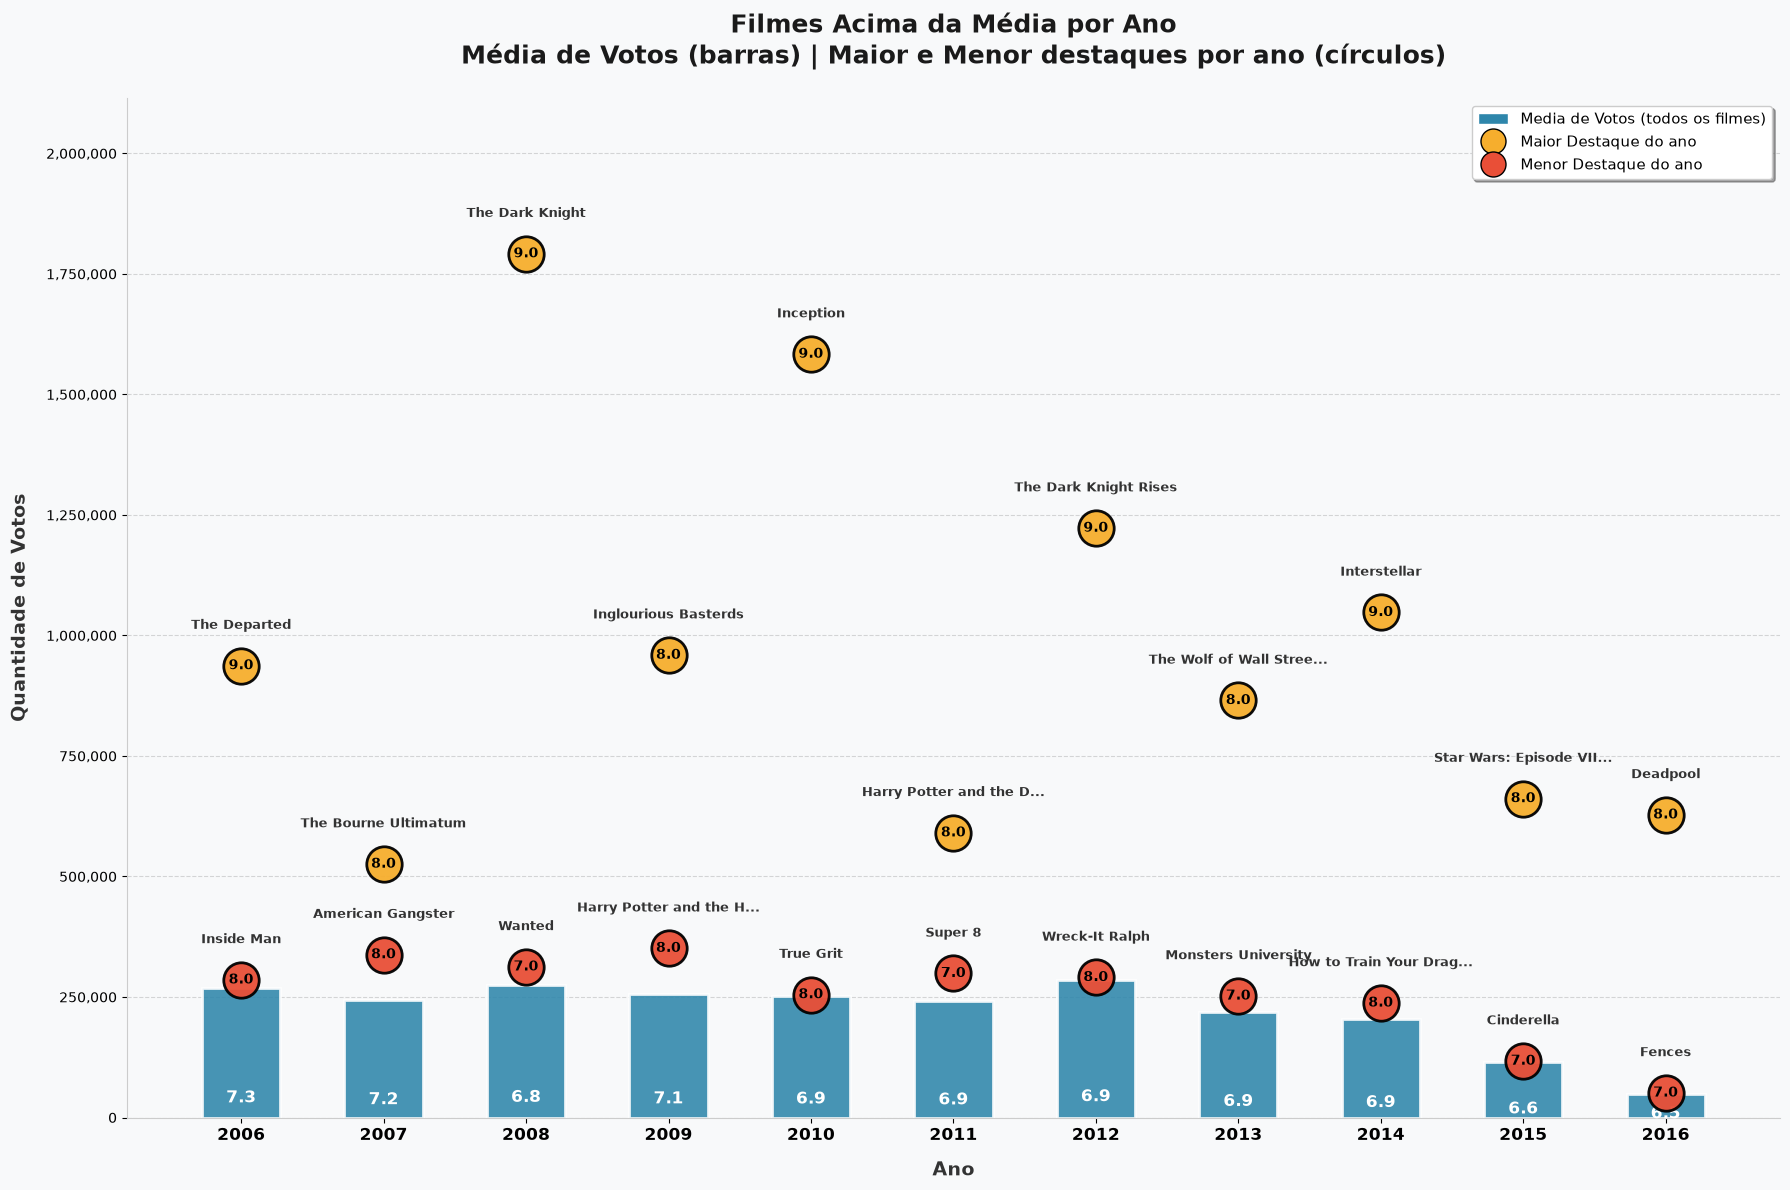

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd


# ============================================================
# PREPARAÇÃO DOS DADOS
# ============================================================

# Barras: média de TODOS os filmes (base_means)
df_bar = base_means[["Year", "avg_votes", "avg_rating"]].copy()

# Melhor filme por ano (mais votos) entre os ACIMA DA MÉDIA
df_max = (
    base_movie.loc[base_movie.groupby("Year")["Votes"].idxmax()]
    [["Year", "Title", "Rating", "Votes"]]
    .assign(tipo="Melhor")
    .reset_index(drop=True)
)

# Pior filme por ano (menos votos) entre os ACIMA DA MÉDIA
df_min = (
    base_movie.loc[base_movie.groupby("Year")["Votes"].idxmin()]
    [["Year", "Title", "Rating", "Votes"]]
    .assign(tipo="Pior")
    .reset_index(drop=True)
)

# ============================================================
# CONFIGURAÇÕES VISUAIS
# ============================================================
COR_BARRA = "#2E86AB"
COR_MELHOR = "#F6AE2D"
COR_PIOR = "#E94F37"
COR_FUNDO = "#F8F9FA"

TAMANHO_CIRCULO = 650      # AUMENTADO: círculos maiores
OFFSET_NOME = 70000        # DIMINUÍDO: nome mais próximo do círculo

# ============================================================
# CRIAR FIGURA
# ============================================================
fig, ax = plt.subplots(figsize=(18, 12))

fig.patch.set_facecolor(COR_FUNDO)
ax.set_facecolor(COR_FUNDO)

# --- BARRAS: Média de votos de TODOS os filmes por ano ---
bars = ax.bar(
    df_bar["Year"],
    df_bar["avg_votes"],
    color=COR_BARRA,
    width=0.55,
    edgecolor="white",
    linewidth=2,
    zorder=2,
    alpha=0.88,
)

# Escrever dados nas barras
for bar, row in zip(bars, df_bar.itertuples()):
    altura = bar.get_height()
    rating_medio = row.avg_rating
    
    # Valor da média de votos no TOPO da barra
    # ax.text(
    #     bar.get_x() + bar.get_width() / 2,
    #     altura + 8000,
    #     f"{altura:,.0f}",
    #     ha="center", va="bottom",
    #     fontsize=10, fontweight="bold", color=COR_BARRA
    # )
    
    # Nota média DENTRO da barra (embaixo)
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        altura * 0.15,
        f"{rating_medio:.1f}",
        ha="center", va="center",
        fontsize=12, fontweight="bold", color="white", zorder=5
    )

# --- CÍRCULOS: Melhor filme do ano ---
ax.scatter(
    df_max["Year"], df_max["Votes"],
    s=TAMANHO_CIRCULO, c=COR_MELHOR,
    edgecolors="black", linewidths=2, zorder=10, alpha=0.95
)

for _, row in df_max.iterrows():
    # Nota dentro do círculo
    ax.text(
        row["Year"], row["Votes"],
        f"{row['Rating']:.1f}",
        ha="center", va="center",
        fontsize=10, fontweight="bold", color="black", zorder=11
    )
    # Nome do filme em cima do círculo
    nome = row["Title"][:22] + "..." if len(row["Title"]) > 22 else row["Title"]
    ax.text(
        row["Year"], row["Votes"] + OFFSET_NOME, nome,
        ha="center", va="bottom",
        fontsize=9, fontweight="bold", color="#333333", zorder=11
    )

# --- CÍRCULOS: Pior filme do ano ---
ax.scatter(
    df_min["Year"], df_min["Votes"],
    s=TAMANHO_CIRCULO, c=COR_PIOR,
    edgecolors="black", linewidths=2, zorder=10, alpha=0.95
)

for _, row in df_min.iterrows():
    # Nota dentro do círculo
    ax.text(
        row["Year"], row["Votes"],
        f"{row['Rating']:.1f}",
        ha="center", va="center",
        fontsize=10, fontweight="bold", color="black", zorder=11
    )
    # Nome do filme em cima do círculo
    nome = row["Title"][:22] + "..." if len(row["Title"]) > 22 else row["Title"]
    ax.text(
        row["Year"], row["Votes"] + OFFSET_NOME, nome,
        ha="center", va="bottom",
        fontsize=9, fontweight="bold", color="#333333", zorder=11
    )

# ============================================================
# ESTILIZAÇÃO FINAL
# ============================================================
ax.set_title("Filmes Acima da Média por Ano\nMédia de Votos (barras) | Maior e Menor destaques por ano (círculos)",
    fontsize=18, fontweight="bold", color="#1a1a1a", pad=25
)

ax.set_xlabel("Ano", fontsize=14, fontweight="bold", color="#333333", labelpad=12)
ax.set_ylabel("Quantidade de Votos", fontsize=14, fontweight="bold", color="#333333", labelpad=12)

ax.set_xticks(range(2006, 2017))
ax.set_xticklabels([str(a) for a in range(2006, 2017)], fontsize=12, fontweight="bold")

ax.grid(axis="y", alpha=0.3, linestyle="--", color="gray", zorder=0)
ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{int(x):,}"))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")

ymax = max(df_bar["avg_votes"].max(), df_max["Votes"].max()) * 1.18
ax.set_ylim(0, ymax)

# Legenda
legend_elements = [
    mpatches.Patch(facecolor=COR_BARRA, edgecolor="white", label="Media de Votos (todos os filmes)"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=COR_MELHOR,
               markeredgecolor='black', markersize=18, label="Maior Destaque do ano"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=COR_PIOR,
               markeredgecolor='black', markersize=18, label="Menor Destaque do ano"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=11,
        frameon=True, fancybox=True, shadow=True, facecolor="white", edgecolor="#cccccc")

plt.tight_layout()
plt.show()

## Análise Final

A análise foi realizada explorando os dados de filmes com foco em métricas de avaliação do público, principalmente nota média e quantidade de votos recebidos ao longo dos anos.

Para interpretação dos resultados, foi construída uma visualização comparando a quantidade média de votos por ano. As barras representam o volume médio de votos, enquanto os valores apresentados indicam a média anual. Também foram destacados pontos de maior e menor representatividade dentro de cada período para facilitar a identificação de comportamentos fora do padrão.

Ao observar a evolução temporal, nota-se uma redução no volume médio de votos nos anos mais recentes, mesmo com o aumento da quantidade de filmes analisados. Esse comportamento pode indicar uma mudança na forma como o público interage e avalia filmes, porém não é possível afirmar uma relação direta com fatores externos, como crescimento das plataformas de streaming, pois não existem variáveis adicionais no conjunto de dados que comprovem essa hipótese.

Também foram observados possíveis padrões entre determinados anos e grupos de filmes com características semelhantes. Entretanto, para validar uma relação entre esses agrupamentos e temas específicos, seriam necessárias análises adicionais envolvendo variáveis como gênero, orçamento, popularidade ou perfil do público.

Como conclusão, o dado que pode ser confirmado pela análise é que existe uma diminuição na quantidade média de votos recebidos pelos filmes nos anos mais recentes, apesar do aumento no volume de produções disponíveis. Esse comportamento sugere uma mudança no engajamento do público ao longo do tempo, mas requer dados complementares para explicar as causas.


## Decisões técnicas

- Análise orientada a métricas de sucesso combinando faturamento, quantidade de votos e avaliação média do público
- Normalização das métricas utilizando valores médios da base para criar critérios comparáveis entre filmes
- Exploração dos dados por período para identificar tendências temporais e possíveis mudanças de comportamento
- Separação entre correlação observada e hipótese — evitando afirmar causas sem evidência suficiente nos dados
- Uso de visualizações para destacar padrões, outliers e filmes com maior relevância dentro das métricas analisadas
- Filtros e agregações aplicados antes da análise gráfica para reduzir ruído e melhorar interpretação
- IA utilizada para: revisão da interpretação dos gráficos e validação das conclusões extraídas dos dados